# Retrieve and plot a sub-domain
In this notebook we demonstrate how to extract a sub-domain. Notice that the downloaded number of points using a sub-domain is the same as without, but anything outside the sub-domain is set to missin values, reducing the size of the data file significantly.

## Load dependencies and create folders
In the first cell we load the relevant libraries for this notebook
We also create folders for downloaded data and plots if we want to save them

In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cdsapi
import cfgrib
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import os
import xarray as xr

## Define your sub-domain
We first define the sub-domain as `[N, W, S, E]`. In our example, we choose the area around Tasiilaq, Greenland.

In [2]:
sub_domain = [67.5, -39, 65, -34]

## Download fields
In the section below, fields are downloaded and stored. We will look at the wind speed at 2:00 AM UTC on Nov 15 2024.

In [ ]:
target_path = os.path.join('data', 'wind_speed_subdomain.grib')


dataset = "reanalysis-pan-carra"
request = {
    "level_type": "single_levels",
    "variable": [
        "10m_wind_direction",
        "10m_wind_speed"
    ],
    "product_type": "forecast",
    "time": ["00:00"],
    "leadtime_hour": ["2"],
    "year": ["2024"],
    "month": ["11"],
    "day": ["15"],
    "data_format": "grib",
    "area": sub_domain
}

client = cdsapi.Client()
client.retrieve(dataset, request).download(target_path)

In [6]:
ds = cfgrib.open_dataset(target_path)
ds

<xarray.Dataset> Size: 198MB
Dimensions:            (y: 2869, x: 2869)
Coordinates:
    latitude           (y, x) float64 66MB ...
    longitude          (y, x) float64 66MB ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B ...
Dimensions without coordinates: y, x
Data variables:
    si10               (y, x) float32 33MB ...
    wdir10             (y, x) float32 33MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             enmi
    GRIB_centreDescription:  Oslo
    GRIB_subCentre:          255
    Conventions:             CF-1.7
    institution:             Oslo
    history:                 2026-06-10T10:33 GRIB to CDM+CF via cfgrib-0.9.1...

## Plot the sub-domain
In this plot we now plot wind speed and direction

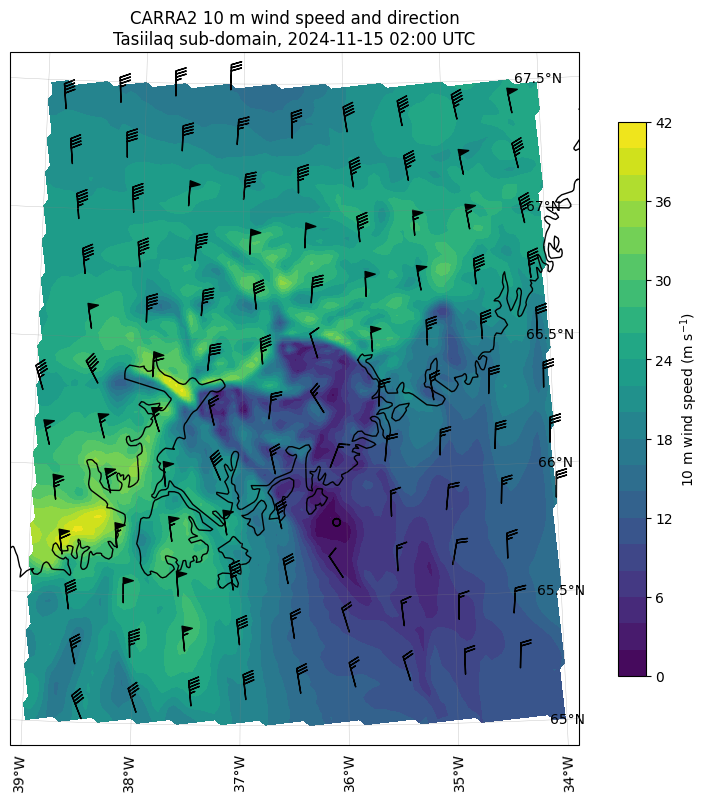

In [ ]:
N, W, S, E = sub_domain
lat = ds.latitude
lon = ((ds.longitude + 180) % 360) - 180 

mask = (lat >= S) & (lat <= N) & (lon >= W) & (lon <= E)
ys, xs = np.where(mask.values)
sub = ds.isel(y=slice(ys.min(), ys.max() + 1),
              x=slice(xs.min(), xs.max() + 1))

sub_lat = sub.latitude
sub_lon = ((sub.longitude + 180) % 360) - 180

spd = sub["si10"]

# Converting to knots for plotting barbs
spd_kt = spd * 1.94384
wdir = np.deg2rad(sub["wdir10"])
u = -spd_kt * np.sin(wdir)
v = -spd_kt * np.cos(wdir)

step = max(1, min(sub.sizes["y"], sub.sizes["x"]) // 10)

proj = ccrs.NorthPolarStereo(central_longitude=-36.6)

fig = plt.figure(figsize=(10, 9))
ax = plt.axes(projection=proj)
ax.set_extent([W - .1, E + .1, S - .1, N + .1], crs=ccrs.PlateCarree())

mesh = ax.contourf(sub_lon, sub_lat, spd, levels=20,
                   transform=ccrs.PlateCarree(), cmap="viridis")
cbar = fig.colorbar(mesh, ax=ax, orientation="vertical", pad=0.05, shrink=0.8)
cbar.set_label("10 m wind speed (m s$^{-1}$)")

bx = sub_lon.values[::step, ::step].ravel()
by = sub_lat.values[::step, ::step].ravel()
bu = u.values[::step, ::step].ravel()
bv = v.values[::step, ::step].ravel()
valid = np.isfinite(bu) & np.isfinite(bv)
ax.barbs(bx[valid], by[valid], bu[valid], bv[valid],
         length=6, transform=ccrs.PlateCarree())

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

fig.savefig(os.path.join("plots", "wind_speed_subdomain.png"),
            dpi=150, bbox_inches="tight")
plt.show()